# CH$_4$ - extend the latitudinal gradient principal components

Extend the latitudinal gradient's principal components back in time.
For CH$_4$, we do this by using the values from ice cores
and a regression against emissions.

## Imports

In [1]:
from collections.abc import Iterator
from contextlib import contextmanager
from functools import partial
from pathlib import Path
from typing import cast

import cf_xarray.units
import matplotlib.axes
import matplotlib.pyplot as plt
import numpy as np
import openscm_units
import pandas as pd
import pint
import pint_xarray
import primap2  # type: ignore
import scipy.optimize  # type: ignore
import tqdm.autonotebook as tqdman
import xarray as xr
from pydoit_nb.config_handling import get_config_for_step_id

import local.binned_data_interpolation
import local.binning
import local.config
import local.latitudinal_gradient
import local.mean_preserving_interpolation
import local.raw_data_processing
import local.regressors
import local.seasonality
import local.xarray_space
import local.xarray_time
from local.config import load_config_from_file

/var/folders/s0/3k_vb4k17flgx7vxv1tx7b9m0000gn/T/ipykernel_40631/3628472251.py:17: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  import tqdm.autonotebook as tqdman


In [2]:
cf_xarray.units.units.define("ppm = 1 / 1000000")
cf_xarray.units.units.define("ppb = ppm / 1000")

pint_xarray.accessors.default_registry = pint_xarray.setup_registry(cf_xarray.units.units)

Quantity = pint.get_application_registry().Quantity  # type: ignore

In [3]:
QuantityOSCM = openscm_units.unit_registry.Quantity

## Define branch this notebook belongs to

In [4]:
step: str = "calculate_ch4_monthly_fifteen_degree_pieces"

## Parameters

In [5]:
config_file: str = "../../dev-config-absolute.yaml"  # config file
step_config_id: str = "only"  # config ID to select for this branch

In [6]:
# Parameters
config_file = "/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/output-bundles/v1.0.0/v1.0.0-config.yaml"
step_config_id = "only"

## Load config

In [7]:
config = load_config_from_file(Path(config_file))
config_step = get_config_for_step_id(config=config, step=step, step_config_id=step_config_id)

config_smooth_law_dome_data = get_config_for_step_id(
    config=config, step="smooth_law_dome_data", step_config_id=config_step.gas
)

config_process_neem = get_config_for_step_id(
    config=config, step="retrieve_and_process_neem_data", step_config_id="only"
)

config_retrieve_misc = get_config_for_step_id(config=config, step="retrieve_misc_data", step_config_id="only")

## Action

### Helper functions

In [8]:
def get_col_assert_single_value(idf: pd.DataFrame, col: str) -> str | float:
    """Get a column's value, asserting that it only has one value"""
    res = idf[col].unique()
    if len(res) != 1:
        raise AssertionError

    return cast(str | float, res[0])

In [9]:
@contextmanager
def axes_vertical_split(
    ncols: int = 2,
) -> Iterator[tuple[matplotlib.axes.Axes, matplotlib.axes.Axes]]:
    """Get two split axes, formatting after exiting the context"""
    fig, axes = plt.subplots(ncols=ncols)

    if isinstance(axes, matplotlib.axes.Axes):
        raise TypeError(type(axes))

    yield (axes[0], axes[1])

    plt.tight_layout()
    plt.show()

### Load data

In [10]:
global_annual_mean_obs_network: xr.DataArray = xr.load_dataarray(  # type: ignore
    config_step.observational_network_global_annual_mean_file
).pint.quantify()
global_annual_mean_obs_network

Magnitude,[1646.820852094638 1659.9908151704774 1672.9498232983997 1686.0799341822894 1698.8642073905241 1708.8882532396535 1719.9836228093257 1732.0285995436536 1744.0833256875658 1746.2544638638456 1749.6687004078276 1757.2590091447728 1758.6470145224164 1762.4813996223993 1772.2844894650389 1779.590724804816 1778.9182295419314 1779.1799675022232 1781.4246086661612 1787.357020805297 1789.1828639234343 1786.4839927938483 1786.248211711816 1790.9319684047914 1800.4309602949477 1804.3069178603637 1809.6775079395593 1813.6029117916596 1818.2588797936153 1824.620466425247 1834.5484724333207 1845.959374022509 1852.3977591829814 1859.3854928114206 1869.5218978539879 1877.2647164703437 1889.4786016246528 1906.18114481266 1922.0865734906138 1935.8751296738]
Units,ppb


In [11]:
lat_grad_eofs_obs_network = xr.load_dataset(
    config_step.observational_network_latitudinal_gradient_eofs_file
).pint.quantify()
lat_grad_eofs_obs_network

Magnitude,[[0.30025018318312763 -0.04561164586679519] [0.2965177211597987 -0.05247176094473515] [0.28669368891135655 -0.13192160300553288] [0.25868274423756865 -0.12013809648787833] [0.21354096993148647 -0.12621426172104994] [0.13572417606734882 -0.05541590622430623] [-0.009763875456997667 -0.003807495208314669] [-0.15477242906216288 0.030927020383364392] [-0.3413313593968472 0.6169182583271611] [-0.38507759994402174 0.1453908598400114] [-0.40439734737743105 -0.3861098085045183] [-0.3954963081830014 -0.6265384717298393]]
Units,ppb
Magnitude,[[-181.96455491656798 -26.899549396283643] [-185.07036998882754 -25.931456273368024] [-187.66848597432005 -29.30254418787181] [-191.95597149687063 -23.555639414150583] [-193.35726365360046 -24.267102482764823] [-189.19301836605945 -26.448557792381166] [-191.84021577313638 -23.063362973218567] [-195.25358261404398 -15.644980568087103] [-184.47372167316075 -9.53623620249803] [-192.7608486126182 -0.2030356999623798] [-199.60426264919815 -4.1309350471026285] [-197.87464470111703 -0.39157903003960653] [-197.8765838415786 3.4812293448022174] [-188.8536126016339 4.975849705822549] [-199.56303374459523 6.204427988571532] [-190.98456783145042 7.254331894702466] [-185.74285457303208 5.3125948291215215] [-189.16391806975932 4.75265960487314] [-188.79057840509148 7.687198637456791] [-200.65959529471274 8.043188347565552] [-188.0157638974525 8.06633885464245] [-196.68731661761015 13.590402250195218] [-192.21199032763428 14.159838698725316] [-197.3187701577451 5.076262360138612] [-202.435064974493 8.757431460027245] [-204.76418639673113 11.006483665925181] [-199.96657588637976 15.231320740657305] [-200.51742635973 12.240867215600435] [-203.4647316418192 5.457914692843327] [-201.18754521482148 8.95337159982959] [-201.33462062202418 9.198991738173637] [-199.87841414146047 6.876955037340297] [-202.07109374842446 3.6778660671565455] [-201.94652441325513 1.5497056906709181] [-190.26960725603203 5.26126806488389] [-196.8554579246131 5.989485812946594] [-203.56222181222165 0.8387463066479733] [-206.72328051568536 6.282478740024786] [-199.40153791374337 4.349681363078166] [-192.67875910417692 6.414157450737971]]
Units,dimensionless


In [12]:
smooth_law_dome = pd.read_csv(config_smooth_law_dome_data.smoothed_median_file)
smooth_law_dome = smooth_law_dome[smooth_law_dome["gas"] == config_step.gas]
smooth_law_dome["source"] = "law_dome"
smooth_law_dome

,year,unit,gas,latitude,longitude,draw,value,source
0,154.0,ppb,ch4,-66.733333,112.833333,median,638.072653,law_dome
1,155.0,ppb,ch4,-66.733333,112.833333,median,637.927098,law_dome
2,156.0,ppb,ch4,-66.733333,112.833333,median,637.844278,law_dome
3,157.0,ppb,ch4,-66.733333,112.833333,median,637.647650,law_dome
4,158.0,ppb,ch4,-66.733333,112.833333,median,637.573103,law_dome
...,...,...,...,...,...,...,...,...
1839,1993.0,ppb,ch4,-66.733333,112.833333,median,1689.444132,law_dome
1840,1994.0,ppb,ch4,-66.733333,112.833333,median,1695.476881,law_dome
1841,1995.0,ppb,ch4,-66.733333,112.833333,median,1700.802546,law_dome
1842,1996.0,ppb,ch4,-66.733333,112.833333,median,1705.823744,law_dome


In [13]:
local.dependencies.save_dependency_into_db(
    db=config.dependency_db,
    gas=config_step.gas,
    dependency_short_name=config_smooth_law_dome_data.source_info_short_name,
)

In [14]:
neem_data = pd.read_csv(config_process_neem.processed_data_with_loc_file)
neem_data["year"] = neem_data["year"].round(0)
neem_data["source"] = "neem"
neem_data.sort_values("year")

,year,value,unit,latitude,longitude,gas,source
256,287.0,712.30,ppb,77.45,-51.06,ch4,neem
255,292.0,702.60,ppb,77.45,-51.06,ch4,neem
254,297.0,705.10,ppb,77.45,-51.06,ch4,neem
253,302.0,694.90,ppb,77.45,-51.06,ch4,neem
252,305.0,699.30,ppb,77.45,-51.06,ch4,neem
...,...,...,...,...,...,...,...
4,1928.0,1112.60,ppb,77.45,-51.06,ch4,neem
3,1933.0,1125.60,ppb,77.45,-51.06,ch4,neem
2,1939.0,1150.30,ppb,77.45,-51.06,ch4,neem
1,1943.0,1175.45,ppb,77.45,-51.06,ch4,neem


In [15]:
local.dependencies.save_dependency_into_db(
    db=config.dependency_db,
    gas=config_step.gas,
    dependency_short_name=config_process_neem.source_info.short_name,
)

### Define some important constants

In [16]:
if not config.ci:
    out_years = np.arange(1, lat_grad_eofs_obs_network["year"].max() + 1)

else:
    out_years = np.arange(1750, lat_grad_eofs_obs_network["year"].max() + 1)

out_years

array([   1,    2,    3, ..., 2021, 2022, 2023])

In [17]:
obs_network_years = lat_grad_eofs_obs_network["year"]
obs_network_years

<xarray.DataArray 'year' (year: 40)> Size: 320B
array([1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995,
       1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007,
       2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019,
       2020, 2021, 2022, 2023])
Coordinates:
  * year     (year) int64 320B 1984 1985 1986 1987 1988 ... 2020 2021 2022 2023

In [18]:
use_extensions_years = np.setdiff1d(out_years, obs_network_years)
use_extensions_years

array([   1,    2,    3, ..., 1981, 1982, 1983])

### Extend PC one

(Zero-indexing, hence this is the second PC)

This is kept constant before the observational network period.

In [19]:
# Quick assertion that things are as expected
exp_n_eofs = 2
if len(lat_grad_eofs_obs_network["eof"]) != exp_n_eofs:
    raise AssertionError("Rethink")

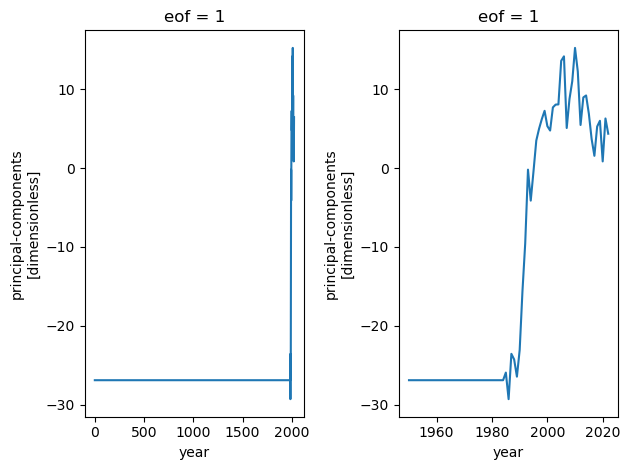

<xarray.DataArray 'principal-components' (year: 2023)> Size: 16kB
array([-26.8995494 , -26.8995494 , -26.8995494 , ...,   6.28247874,
         4.34968136,   6.41415745])
Coordinates:
    eof      int64 8B 1
  * year     (year) int64 16kB 1 2 3 4 5 6 7 ... 2018 2019 2020 2021 2022 2023
Attributes:
    description:  Principal components for the latitudinal gradient EOFs
    units:        dimensionless

In [20]:
allyears_pc1 = lat_grad_eofs_obs_network["principal-components"].sel(eof=1).copy()
allyears_pc1 = allyears_pc1.pint.dequantify().interp(
    year=out_years, kwargs={"fill_value": allyears_pc1.data[0].m}
)

with axes_vertical_split() as axes:
    allyears_pc1.plot(ax=axes[0])
    allyears_pc1.sel(year=range(1950, 2023)).plot(ax=axes[1])

allyears_pc1

### Extend PC zero

(Zero-indexing, hence this is the first PC)

This happens in a few steps.

#### Optimise PC0 to match Law Dome and NEEM data

Over the period where we have both these timeseries.

A quick check below.
We do this because we do the scaling independent of the global-mean.
This only makes sense if the EOFs have a spatial-mean of zero,
because then we can change the PCs however and the global-mean
will not be affected.

In [21]:
np.testing.assert_allclose(
    local.xarray_space.calculate_global_mean_from_lon_mean(lat_grad_eofs_obs_network["eofs"]).data.m,
    0.0,
    atol=1e-10,
)

In [22]:
law_dome_lat = get_col_assert_single_value(smooth_law_dome, "latitude")
law_dome_lat

-66.73333333333333

In [23]:
law_dome_lat_nearest = float(lat_grad_eofs_obs_network.sel(lat=law_dome_lat, method="nearest")["lat"])
law_dome_lat_nearest

-67.5

In [24]:
neem_lat = get_col_assert_single_value(neem_data, "latitude")
neem_lat

77.45

In [25]:
neem_lat_nearest = float(lat_grad_eofs_obs_network.sel(lat=neem_lat, method="nearest")["lat"])
neem_lat_nearest

82.5

In [26]:
conc_unit = get_col_assert_single_value(smooth_law_dome, "unit")
conc_unit

'ppb'

In [27]:
neem_unit = get_col_assert_single_value(neem_data, "unit")
if neem_unit != conc_unit:
    raise AssertionError

neem_unit

'ppb'

In [28]:
def diff_from_ice_cores(
    x: tuple[float, float], pc1: float, eofs: xr.DataArray, ice_core_data: xr.DataArray
) -> float:
    """
    Calculate the difference from the ice core data

    Parameters
    ----------
    x
        Current x-vector.
        Element zero should be the global-mean,
        element one is the value of pc0.

    pc1
        Value of PC1 to use when calculating the value at each latitude.

    eofs
        EOFs to use when calculating the value at each latitude.

    ice_core_data
        Ice core data to compare to

    Returns
    -------
        Area-weighted squared difference between the model's prediction
        and the ice core values.
    """
    global_mean, pc0 = x

    pcs = xr.DataArray([pc0, pc1], dims=["eof"], coords=dict(eof=[0, 1]))

    lat_grad = pcs @ eofs
    lat_grad.name = "lat_grad"

    lat_resolved = lat_grad + Quantity(global_mean, conc_unit)

    lat_resolved.name = "lat_resolved"
    lat_resolved = (
        lat_resolved.to_dataset().cf.add_bounds("lat").pint.quantify({"lat_bounds": "degrees_north"})
    )

    diff_squared = (lat_resolved - ice_core_data) ** 2
    if not str(diff_squared["lat_resolved"].data.units) == f"{conc_unit} ** 2":
        raise AssertionError(diff_squared["lat_resolved"].data.units)

    area_weighted_diff_squared = local.xarray_space.calculate_area_weighted_mean_latitude_only(
        diff_squared, variables=["lat_resolved"]
    )["lat_resolved"].pint.dequantify()

    return cast(float, area_weighted_diff_squared**0.5)

In [29]:
years_to_optimise = np.setdiff1d(neem_data["year"], obs_network_years.data)
years_to_optimise = years_to_optimise[np.isin(years_to_optimise, out_years)]
years_to_optimise

array([ 287.,  292.,  297.,  302.,  305.,  313.,  318.,  323.,  328.,
        333.,  338.,  343.,  348.,  352.,  365.,  370.,  375.,  380.,
        385.,  390.,  393.,  401.,  405.,  414.,  419.,  422.,  428.,
        433.,  440.,  445.,  450.,  455.,  460.,  464.,  469.,  529.,
        533.,  541.,  546.,  551.,  556.,  561.,  565.,  572.,  577.,
        581.,  587.,  594.,  599.,  604.,  609.,  616.,  622.,  628.,
        633.,  636.,  646.,  650.,  657.,  664.,  666.,  674.,  678.,
        684.,  689.,  693.,  700.,  706.,  713.,  719.,  722.,  749.,
        758.,  764.,  768.,  774.,  779.,  783.,  790.,  794.,  799.,
        804.,  809.,  814.,  819.,  829.,  834.,  838.,  847.,  853.,
        857.,  862.,  868.,  872.,  878.,  882.,  886.,  894.,  899.,
        902.,  910.,  915.,  920.,  925.,  929.,  945.,  950.,  955.,
        960.,  963.,  974.,  979.,  984.,  989.,  994.,  999., 1004.,
       1009., 1013., 1133., 1139., 1144., 1149., 1154., 1158., 1164.,
       1169., 1173.,

In [30]:
iter_df = (
    pd.concat([neem_data, smooth_law_dome])
    .set_index("year")
    .loc[years_to_optimise]
    .set_index("source", append=True)
)
# iter_df

Note: we could harmonise here before doing the optimisation.
I'm not sure what the right answer is,
but I think you can equally argue that you should figure out
the PC from the raw data,
then harmonise the global-mean later
so that the gradient isn't affected by harmonisation,
only the centre.

In [31]:
optimised = []
x0 = (1100, -70)
eofs = lat_grad_eofs_obs_network["eofs"]
for year, ydf in tqdman.tqdm(iter_df.groupby("year")):
    exp_n_ice_core_data_points = 2
    if ydf.shape[0] != exp_n_ice_core_data_points:
        msg = "Should have both NEEM and law dome data here..."
        raise AssertionError(msg)

    ice_core_data_year = xr.DataArray(
        data=[
            [
                ydf.loc[(year, "neem")]["value"],  # type: ignore
                ydf.loc[(year, "law_dome")]["value"],  # type: ignore
            ]
        ],
        dims=["year", "lat"],
        coords=dict(
            year=[year],
            lat=[neem_lat_nearest, law_dome_lat_nearest],
        ),
        attrs={"units": conc_unit},
    ).pint.quantify()

    diff_from_ice_cores_year = partial(
        diff_from_ice_cores,
        eofs=eofs,
        pc1=float(allyears_pc1.sel(year=year)),
        ice_core_data=ice_core_data_year,
    )

    min_res = scipy.optimize.minimize(
        diff_from_ice_cores_year,
        x0=x0,
        method="Nelder-Mead",
    )

    optimised.append([year, min_res.x[0], min_res.x[1]])

    x0 = min_res.x
    # if year > 300:
    #     break

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 257/257 [01:43<00:00,  2.47it/s]


  1%|█▌                                                                                                                                                                                                       | 2/257 [00:01<02:19,  1.83it/s]

  1%|██▎                                                                                                                                                                                                      | 3/257 [00:01<02:01,  2.09it/s]

  2%|███▏                                                                                                                                                                                                     | 4/257 [00:01<02:00,  2.10it/s]

  2%|███▉                                                                                                                                                                                                     | 5/257 [00:02<01:56,  2.16it/s]

...

 99%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋  | 254/257 [01:50<00:01,  2.08it/s]

 99%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍ | 255/257 [01:51<00:00,  2.10it/s]

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▏| 256/257 [01:51<00:00,  2.09it/s]

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 257/257 [01:52<00:00,  2.03it/s]

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 257/257 [01:52<00:00,  2.29it/s]

Process the results.

In [32]:
optimised_ar = np.array(optimised)

global_annual_mean_optimised = xr.DataArray(
    name="global_annual_mean_optimised",
    data=optimised_ar[:, 1],
    dims=["year"],
    coords=dict(year=optimised_ar[:, 0]),
    attrs=dict(units=conc_unit),
).pint.quantify()

pc0_optimised = (
    xr.DataArray(
        name="pc0_optimised",
        data=optimised_ar[:, 2],
        dims=["year"],
        coords=dict(year=optimised_ar[:, 0]),
        attrs=dict(units="dimensionless"),
    )
    .assign_coords(eof=0)
    .pint.quantify()
)
pc0_optimised

<xarray.DataArray 'pc0_optimised' (year: 257)> Size: 2kB
<Quantity([ -70.49148539  -56.77192379  -60.71138027  -46.86034225  -53.86903107
  -43.3251238   -42.54796563  -51.34405949  -50.20341603  -50.76229616
  -51.72150296  -53.9488971   -58.42449761  -54.01756221  -51.41150557
  -51.29253627  -40.631805    -47.24742464  -45.39228319  -40.84646082
  -40.72541829  -39.92706472  -35.85644926  -50.98871254  -53.29645986
  -46.68316688  -51.75893339  -60.89019259  -62.16378126  -64.71880751
  -57.89437474  -47.00862481  -44.20455164  -40.77438995  -37.73794025
    2.27406641   -5.09690725   -3.91833819   -4.79094307   -8.82045268
   -7.9894337    -6.3140162   -19.26613335  -25.51878766  -25.01919131
  -15.45877198  -16.69804392  -22.81740565  -19.22406887  -11.27373104
   -9.81488774  -12.06599354  -14.13624634  -12.67125339  -12.1547441
  -13.01577037  -20.75472863  -25.69574742  -33.46303795  -28.44730516
  -27.37418563  -24.103007    -18.24138002  -24.08638664  -24.44743443
  -33.71987428  -41.04243675  -39.12923879  -26.5450138   -27.86921102
  -52.34834577  -39.35937097  -20.75975077   -8.76997401  -14.54043118
   -9.04079507   -0.55434805    1.7476169     2.87794703    1.00621115
    0.72029898    3.63007471  -13.94779478  -22.61410521  -23.42557849
  -24.98153719  -36.08153601  -26.95977001  -20.70854559  -19.58688259
  -31.90062095  -37.15145441  -39.45271374  -41.45054107  -43.86259107
  -37.92702308  -37.53240437  -31.75912386  -32.72791104  -57.13985059
...
  -60.55352108  -62.08719608  -57.56719094  -52.91587833  -50.60162072
  -45.66844709  -38.09934525  -30.21772216  -33.75112938  -35.19435963
  -39.60206339  -25.90978919  -30.63533001  -32.08468899  -28.4804898
  -28.84517953  -29.67715711  -29.46099462  -29.60528364  -27.33163936
  -34.49697841  -39.03016588  -36.02580197  -53.47980666  -44.81024633
  -48.10756262  -55.36067229  -56.10857004  -58.77193275  -60.6589953
  -70.02785666  -78.07086529  -71.88947848  -74.30609559  -67.66920381
  -68.5749133   -48.44987114  -39.79281415  -35.39077606  -31.66236493
  -33.40346825  -36.01381506  -35.41478488  -36.41670591  -47.41923516
  -54.65783539  -51.57953714  -50.19144551  -49.04710212  -55.5101746
  -44.88967777  -52.38998935  -57.22361299  -52.25954345  -51.25737485
  -38.69242294  -43.90818242  -47.56540403  -49.08317288  -50.43746205
  -49.64527417  -51.70306647  -63.90142959  -48.70125798  -54.90638543
  -47.19547324  -54.10014771  -56.24846855  -61.88126835  -59.06097311
  -64.32986879  -58.98836067  -54.35941374  -55.98793914  -54.49524941
  -55.63905173  -59.09418446  -61.83304271  -66.86804637  -68.53916403
  -69.49601923  -71.39031417  -68.86172346  -70.31126713  -77.99811392
 -100.43144301 -117.54116063 -121.94597278 -129.73313851 -140.03449756
 -128.535734   -112.33553288 -124.92757425 -101.96259147  -94.6305669
 -109.86024559 -168.03334235], 'dimensionless')>
Coordinates:
  * year     (year) float64 2kB 287.0 292.0 297.0 ... 1.943e+03 1.948e+03
    eof      int64 8B 0

Linearly interpolate the optimised values.

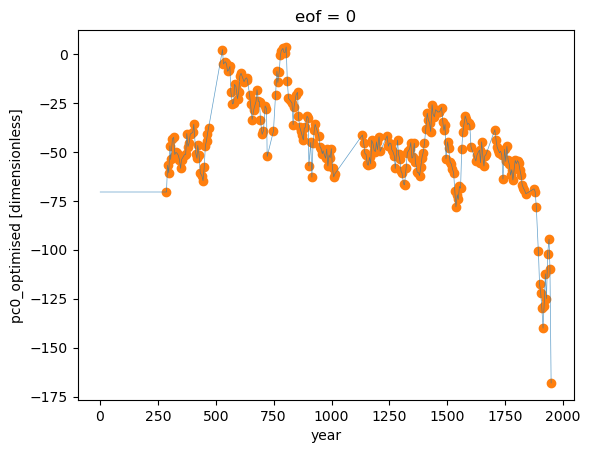

In [33]:
pc0_optimised_years_to_optimise = pc0_optimised.pint.dequantify().interp(year=years_to_optimise)
# Assuming PC0 is constant before the start of the NEEM data.
pc0_optimised_years_to_optimise_back_to_year_one = pc0_optimised_years_to_optimise.pint.dequantify().interp(
    year=np.arange(out_years[0], years_to_optimise[-1] + 1),
    kwargs={"fill_value": pc0_optimised.data[0].m},
)

pc0_optimised.pint.dequantify().plot.scatter(x="year", color="tab:orange")
pc0_optimised_years_to_optimise_back_to_year_one.plot(linewidth=0.5, alpha=0.7, zorder=1)

#### Use a regression against emissions to fill in the gap

There is a gap between the observational network period
and the optimised ice core period.
We fill this using a regression against emissions.

In [34]:
primap_full = primap2.open_dataset(
    config_retrieve_misc.primap.raw_dir / config_retrieve_misc.primap.download_url.url.split("/")[-1]
)

primap_fossil_ch4_emissions = (
    local.xarray_time.convert_time_to_year_month(primap_full)
    .sel(
        **{
            "category (IPCC2006_PRIMAP)": "M.0.EL",
            "scenario (PRIMAP-hist)": "HISTTP",
            "area (ISO3)": "EARTH",
            "month": 1,
        }
    )[config_step.gas.upper()]
    .squeeze()
    .pint.to("MtCH4 / yr")
    .reset_coords(drop=True)
)

primap_fossil_ch4_emissions

<xarray.DataArray 'CH4' (year: 273)> Size: 2kB
<Quantity([ 26.929128  27.003     27.07685   27.150631  27.22439   27.298103
  27.375955  27.449576  27.523152  27.596683  27.670144  27.743608
  27.81081   27.877965  27.945074  28.012137  28.087422  28.154391
  28.221314  28.28819   28.35502   28.587421  28.811058  29.034627
  29.258129  29.481564  29.714105  29.937405  30.160638  30.383804
  30.606927  30.736549  30.854473  30.972356  31.090149  31.207905
  31.34042   31.45804   31.575571  31.69306   31.810483  31.865655
  31.907618  31.948124  31.988394  32.028742  32.075557  32.123107
  32.169619  32.218147  32.265975  32.467366  32.706827  32.892841
  33.120291  33.305333  33.517511  33.723259  33.919383  34.12022
  34.344579  34.508187  34.668079  34.818213  34.972835  35.130711
  35.30202   35.458742  35.605892  35.75695   35.910465  36.172766
  36.443664  36.718609  36.992395  37.261239  37.522995  37.814709
  38.077194  38.334     38.705968  38.951032  39.225044  39.502424
  39.787355  40.061654  40.420315  40.682114  40.968209  41.247582
  41.545812  41.79689   42.05531   42.299917  42.564867  42.86803
  43.078159  43.384913  43.595128  43.871178  44.168823  44.337626
  44.57332   44.837922  45.270224  45.500011  45.802994  46.014215
  46.219144  46.53833   46.915653  47.210263  47.44242   47.833733
  48.203722  48.548743  48.908799  49.192515  49.437714  49.793652
...
  73.348874  75.10615   75.150444  76.178074  77.161327  77.955453
  78.831006  80.30586   79.487681  79.873579  81.357041  82.4778
  82.256615  81.255409  83.506241  82.105304  83.836944  86.57341
  87.576752  88.414064  88.737249  91.261793  91.876202  93.901147
  94.035764  93.617603  93.546956  95.087406  97.373125  99.126896
 101.8687   104.06915  104.40079  106.41804  108.7245   110.56732
 111.87348  114.09796  115.72863  114.75575  118.19997  122.19513
 124.17115  125.90773  129.164    133.52632  136.61447  140.1139
 144.01956  151.04578  156.03833  160.96622  164.63797  171.98352
 177.18316  179.12492  182.35829  187.13148  191.25178  196.63871
 204.10608  207.07731  210.80881  217.50799  223.49402  224.15355
 228.83734  234.51671  235.69245  239.47565  242.99339  246.24681
 247.68595  253.87756  252.84401  247.35381  250.55764  251.08738
 254.72746  258.56382  262.06911  264.88004  269.30326  275.35741
 276.87484  275.96119  275.63148  276.27963  278.75452  282.87475
 285.81477  285.76128  283.68967  285.26508  290.58422  290.46512
 290.27421  297.98505  304.4388   309.80798  315.84021  318.72632
 322.45863  320.70652  326.95237  336.31352  339.7233   338.73524
 341.7271   342.352    343.27241  348.79046  353.73427  355.92799
 352.14682  357.63137  364.32246 ], 'megatCH4 / yr')>
Coordinates:
  * year     (year) int64 2kB 1750 1751 1752 1753 1754 ... 2019 2020 2021 2022
Attributes:
    entity:   CH4

In [35]:
regression_years = np.intersect1d(lat_grad_eofs_obs_network["year"], primap_fossil_ch4_emissions["year"])
regression_years

array([1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994,
       1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005,
       2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016,
       2017, 2018, 2019, 2020, 2021, 2022])

In [36]:
primap_regression_data = primap_fossil_ch4_emissions.sel(year=regression_years)
primap_regression_data

Magnitude,[254.7274599999999 258.5638199999999 262.06910999999985 264.8800399999999 269.3032599999999 275.35740999999985 276.8748399999999 275.9611899999999 275.63147999999984 276.2796299999999 278.7545199999999 282.8747499999999 285.8147699999999 285.7612799999999 283.68966999999986 285.2650799999999 290.58421999999985 290.4651199999999 290.2742099999999 297.9850499999999 304.43879999999984 309.8079799999999 315.8402099999999 318.7263199999999 322.45862999999986 320.7065199999999 326.95236999999986 336.31351999999987 339.7232999999998 338.73523999999986 341.72709999999984 342.35199999999986 343.2724099999998 348.7904599999999 353.73426999999987 355.92798999999985 352.1468199999999 357.63136999999983 364.32245999999986]
Units,megatCH4/yr


In [37]:
pc0_obs_network_regression = lat_grad_eofs_obs_network["principal-components"].sel(
    eof=0, year=regression_years
)
pc0_obs_network_regression

Magnitude,[-181.96455491656798 -185.07036998882754 -187.66848597432005 -191.95597149687063 -193.35726365360046 -189.19301836605945 -191.84021577313638 -195.25358261404398 -184.47372167316075 -192.7608486126182 -199.60426264919815 -197.87464470111703 -197.8765838415786 -188.8536126016339 -199.56303374459523 -190.98456783145042 -185.74285457303208 -189.16391806975932 -188.79057840509148 -200.65959529471274 -188.0157638974525 -196.68731661761015 -192.21199032763428 -197.3187701577451 -202.435064974493 -204.76418639673113 -199.96657588637976 -200.51742635973 -203.4647316418192 -201.18754521482148 -201.33462062202418 -199.87841414146047 -202.07109374842446 -201.94652441325513 -190.26960725603203 -196.8554579246131 -203.56222181222165 -206.72328051568536 -199.40153791374337]
Units,dimensionless


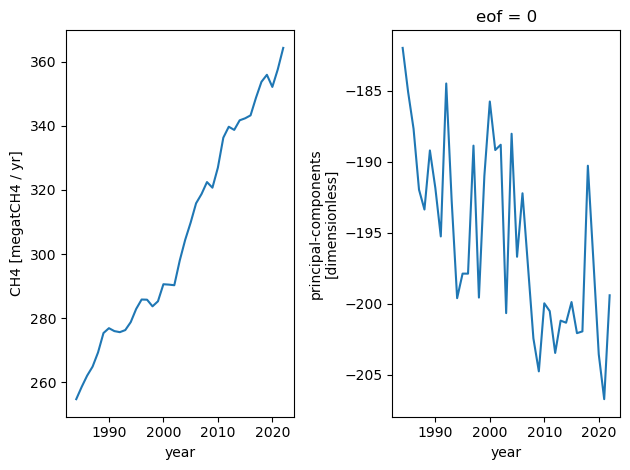

In [38]:
with axes_vertical_split() as axes:
    primap_regression_data.plot(ax=axes[0])
    pc0_obs_network_regression.plot(ax=axes[1])

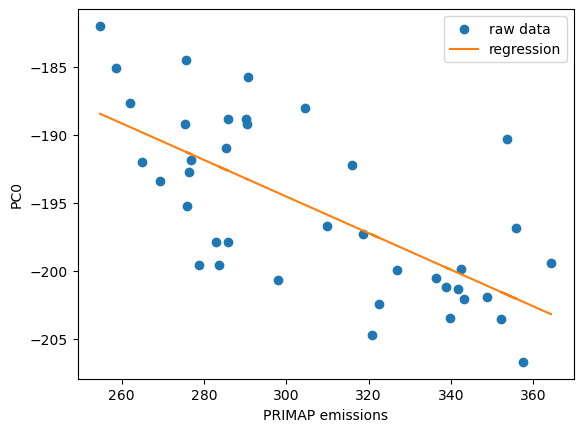

In [39]:
x = QuantityOSCM(primap_regression_data.data.m, str(primap_regression_data.data.units))
A = np.vstack([x.m, np.ones(x.size)]).T
y = QuantityOSCM(pc0_obs_network_regression.data.m, str(pc0_obs_network_regression.data.units))

res = np.linalg.lstsq(A, y.m, rcond=None)
m, c = res[0]
m = QuantityOSCM(m, (y / x).units)
c = QuantityOSCM(c, y.units)

latitudinal_gradient_pc0_ch4_fossil_emissions_regression = local.regressors.LinearRegressionResult(m=m, c=c)

fig, ax = plt.subplots()
ax.scatter(x.m, y.m, label="raw data")
ax.plot(x.m, (m * x + c).m, color="tab:orange", label="regression")
ax.set_ylabel("PC0")
ax.set_xlabel("PRIMAP emissions")
ax.legend()

In [40]:
years_to_fill_with_regression = np.setdiff1d(
    primap_fossil_ch4_emissions["year"],
    pc0_optimised_years_to_optimise_back_to_year_one["year"],
)
years_to_fill_with_regression = np.setdiff1d(
    years_to_fill_with_regression, pc0_obs_network_regression["year"]
)

years_to_fill_with_regression

array([1949, 1950, 1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959,
       1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970,
       1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981,
       1982, 1983])

In [41]:
pc0_emissions_extended = (
    m * primap_fossil_ch4_emissions.sel(year=years_to_fill_with_regression).pint.quantify() + c
)
pc0_emissions_extended = pc0_emissions_extended.assign_coords(eof=0)
pc0_emissions_extended = pc0_emissions_extended.assign_coords(eof=0)
pc0_emissions_extended

Magnitude,[-171.06997493794998 -171.5089016545481 -172.09691763428887 -172.5131827289716 -172.98488603363154 -173.51134683692757 -174.45844141897888 -175.1314088261509 -175.7956604322698 -176.29059149501006 -177.2807299488568 -177.98161191278865 -178.24335014125916 -178.67919006781528 -179.32258899186 -179.87798204906943 -180.6041096421265 -181.61066874064215 -182.01117368284838 -182.51415870650612 -183.4171701525164 -184.22405302566818 -184.31295392682134 -184.94430223821297 -185.70984908366682 -185.8683321633172 -186.37828605357632 -186.85245744232662 -187.2909999950986 -187.48498789994832 -188.31958179042923 -188.18026511584756 -187.4402173128499 -187.8720754150462 -187.94348136076036]
Units,dimensionless


#### Concatenate the pieces of PC0

Join:

- optimised, interpolated based on Law Dome and NEEM
- extended based on regression with emissions
- raw values derived from the observational network

In [42]:
pc0_obs_network_raw_years = np.setdiff1d(
    lat_grad_eofs_obs_network["principal-components"].sel(
        eof=0,
    )["year"],
    pc0_obs_network_regression["year"],
)

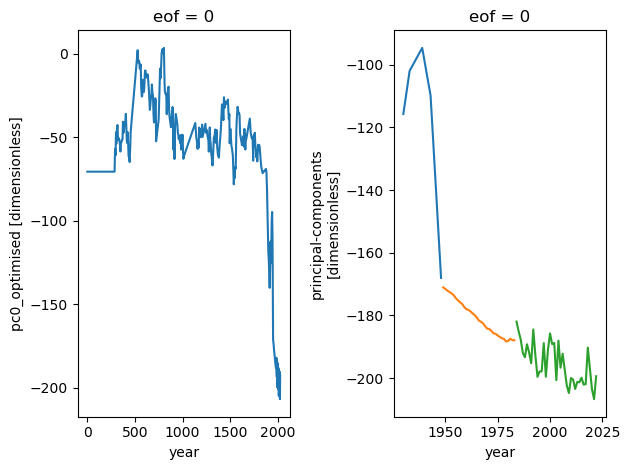

Magnitude,[-70.49148538803955 -70.49148538803955 -70.49148538803955 ... -206.72328051568536 -199.40153791374337 -192.67875910417692]
Units,dimensionless


In [43]:
allyears_pc0 = xr.concat(
    [
        pc0_optimised_years_to_optimise_back_to_year_one,
        pc0_emissions_extended,
        pc0_obs_network_regression,
        lat_grad_eofs_obs_network["principal-components"].sel(eof=0, year=pc0_obs_network_raw_years),
    ],
    "year",
)

with axes_vertical_split() as axes:
    allyears_pc0.plot(ax=axes[0])

    pc0_optimised_years_to_optimise_back_to_year_one.sel(
        year=np.arange(1930, pc0_optimised_years_to_optimise_back_to_year_one["year"].max() + 1)
    ).plot(ax=axes[1])
    pc0_emissions_extended.plot(ax=axes[1])
    pc0_obs_network_regression.plot(ax=axes[1])

allyears_pc0

### Join the PCs back together

In [44]:
allyears_pcs = xr.concat([allyears_pc0, allyears_pc1], "eof").pint.dequantify().pint.quantify()
allyears_pcs

Magnitude,[[-70.49148538803955 -70.49148538803955 -70.49148538803955 ... -206.72328051568536 -199.40153791374337 -192.67875910417692] [-26.899549396283643 -26.899549396283643 -26.899549396283643 ... 6.282478740024786 4.349681363078166 6.414157450737971]]
Units,dimensionless


### Join PCs and EOFs back together

In [45]:
allyears_pcs.name = "principal-components"
out = xr.merge([allyears_pcs, lat_grad_eofs_obs_network["eofs"]])
out

Magnitude,[[-70.49148538803955 -70.49148538803955 -70.49148538803955 ... -206.72328051568536 -199.40153791374337 -192.67875910417692] [-26.899549396283643 -26.899549396283643 -26.899549396283643 ... 6.282478740024786 4.349681363078166 6.414157450737971]]
Units,dimensionless
Magnitude,[[0.30025018318312763 -0.04561164586679519] [0.2965177211597987 -0.05247176094473515] [0.28669368891135655 -0.13192160300553288] [0.25868274423756865 -0.12013809648787833] [0.21354096993148647 -0.12621426172104994] [0.13572417606734882 -0.05541590622430623] [-0.009763875456997667 -0.003807495208314669] [-0.15477242906216288 0.030927020383364392] [-0.3413313593968472 0.6169182583271611] [-0.38507759994402174 0.1453908598400114] [-0.40439734737743105 -0.3861098085045183] [-0.3954963081830014 -0.6265384717298393]]
Units,ppb


Quick check that our output matches the observational network in the years they overlap.

In [46]:
xr.testing.assert_allclose(
    (out["principal-components"] @ out["eofs"]).sel(year=regression_years),
    (lat_grad_eofs_obs_network["principal-components"] @ lat_grad_eofs_obs_network["eofs"]).sel(
        year=regression_years
    ),
)

## Save

In [47]:
config_step.latitudinal_gradient_allyears_pcs_eofs_file.parent.mkdir(exist_ok=True, parents=True)
out.pint.dequantify().to_netcdf(config_step.latitudinal_gradient_allyears_pcs_eofs_file)
out

Magnitude,[[-70.49148538803955 -70.49148538803955 -70.49148538803955 ... -206.72328051568536 -199.40153791374337 -192.67875910417692] [-26.899549396283643 -26.899549396283643 -26.899549396283643 ... 6.282478740024786 4.349681363078166 6.414157450737971]]
Units,dimensionless
Magnitude,[[0.30025018318312763 -0.04561164586679519] [0.2965177211597987 -0.05247176094473515] [0.28669368891135655 -0.13192160300553288] [0.25868274423756865 -0.12013809648787833] [0.21354096993148647 -0.12621426172104994] [0.13572417606734882 -0.05541590622430623] [-0.009763875456997667 -0.003807495208314669] [-0.15477242906216288 0.030927020383364392] [-0.3413313593968472 0.6169182583271611] [-0.38507759994402174 0.1453908598400114] [-0.40439734737743105 -0.3861098085045183] [-0.3954963081830014 -0.6265384717298393]]
Units,ppb


In [48]:
config_step.latitudinal_gradient_pc0_ch4_fossil_emissions_regression_file.parent.mkdir(
    exist_ok=True, parents=True
)
with open(config_step.latitudinal_gradient_pc0_ch4_fossil_emissions_regression_file, "w") as fh:
    fh.write(local.config.converter_yaml.dumps(latitudinal_gradient_pc0_ch4_fossil_emissions_regression))

latitudinal_gradient_pc0_ch4_fossil_emissions_regression

LinearRegressionResult(m=<Quantity(-0.13479432497862384, 'yr / megatCH4')>, c=<Quantity(-154.09832746300916, 'dimensionless')>)

In [49]:
primap_regression_data

Magnitude,[254.7274599999999 258.5638199999999 262.06910999999985 264.8800399999999 269.3032599999999 275.35740999999985 276.8748399999999 275.9611899999999 275.63147999999984 276.2796299999999 278.7545199999999 282.8747499999999 285.8147699999999 285.7612799999999 283.68966999999986 285.2650799999999 290.58421999999985 290.4651199999999 290.2742099999999 297.9850499999999 304.43879999999984 309.8079799999999 315.8402099999999 318.7263199999999 322.45862999999986 320.7065199999999 326.95236999999986 336.31351999999987 339.7232999999998 338.73523999999986 341.72709999999984 342.35199999999986 343.2724099999998 348.7904599999999 353.73426999999987 355.92798999999985 352.1468199999999 357.63136999999983 364.32245999999986]
Units,megatCH4/yr


In [53]:
import json
json.dumps([int(v) for v in years_to_fill_with_regression])

'[1949, 1950, 1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959, 1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983]'

In [54]:
json.dump?

Signature:
json.dump(
    obj,
    fp,
    *,
    skipkeys=False,
    ensure_ascii=True,
    check_circular=True,
    allow_nan=True,
    cls=None,
    indent=None,
    separators=None,
    default=None,
    sort_keys=False,
    **kw,
)
Docstring:
Serialize ``obj`` as a JSON formatted stream to ``fp`` (a
``.write()``-supporting file-like object).

If ``skipkeys`` is true then ``dict`` keys that are not basic types
(``str``, ``int``, ``float``, ``bool``, ``None``) will be skipped
instead of raising a ``TypeError``.

If ``ensure_ascii`` is false, then the strings written to ``fp`` can
contain non-ASCII characters if they appear in strings contained in
``obj``. Otherwise, all such characters are escaped in JSON strings.

If ``check_circular`` is false, then the circular reference check
for container types will be skipped and a circular reference will
result in an ``RecursionError`` (or worse).

If ``allow_nan`` is false, then it will be a ``ValueError`` to
serialize out of range ``float``